# Basic Galton Board Mathematical Simulation

This notebook walks through the simulation of a mass-point sized ball through a custom galton board configuration. It results in the visualization of the path taken by the ball throughout the simulation. Note that this simulation does not depend on an incremental time-frame simulation, but is based on mathematical descriptions of the physical trajectory of the ball in continuous time. 

The mathematical description comes from the paper written by Kozlov and Mitrofanova on the subject in 2003.

In [61]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.cm import get_cmap

import sympy as sym
from sympy import symbols, Eq, solve

x, y = symbols('x y')

First we generate the grid in a way which is easy for Sympy to understand.

In [85]:
def generate_circle_geometry(n_first_row, n_rows, d, h_init, r_custom, WALL_PADDING=0):
    """Generates SymPy circle objects and equations based on grid constraints.

    Building DOWNWARD from the initial row.
    """
    x, y = sym.symbols("x y")
    circles_data = []
    max_edge_distance = 0  # Track the furthest edge from x=0

    # Calculate row height step for an equilateral triangle lattice
    row_height_step = d * (3**0.5) / 2

    for row_idx in range(n_rows):
        # Determine number of circles in this row (staggered n, n-1, n, n-1...)
        is_even_row = row_idx % 2 == 0
        row_count = n_first_row if is_even_row else n_first_row - 1

        # Subtract the step so subsequent rows go DOWNWARD
        y_center = -h_init - (row_idx * row_height_step)

        # Calculate the starting X coordinate to keep the row symmetric about x=0
        start_x = -((row_count - 1) * d) / 2

        for col_idx in range(row_count):
            x_center = start_x + (col_idx * d)

            # Track the maximum absolute distance from x=0 to the outer edge of the circle
            furthest_edge = abs(x_center) + r_custom
            if furthest_edge > max_edge_distance:
                max_edge_distance = furthest_edge

            # SymPy Equation: (x - x_c)^2 + (y - y_c)^2 = r_custom^2
            equation = sym.Eq(
                (x - x_center) ** 2 + (y - y_center) ** 2, r_custom**2
            )

            circles_data.append(
                {
                    "center": (x_center, y_center),
                    "radius": r_custom,
                    "eq": equation,
                }
            )

    # Calculate final WALL_DISTANCE by adding the padding
    WALL_DISTANCE = max_edge_distance + WALL_PADDING

    return circles_data, WALL_DISTANCE

Then we create a function to quickly check if we've done it correctly or not by plotting all the circles.

In [95]:
def visualize_circles(circles_data, H_INIT, N_ROWS, DISTANCE, H_FINAL, WALL_DISTANCE):
    """Visualizes the generated circles using Matplotlib."""
    fig, ax = plt.subplots(figsize=(8, 8))

    for c in circles_data:
        x_c, y_c = c["center"]
        r = c["radius"]

        circle_patch = plt.Circle(
            (x_c, y_c), r, edgecolor="darkgreen", facecolor="lightgreen", alpha=0.4
        )
        ax.add_patch(circle_patch)
        ax.plot(x_c, y_c, "ko", markersize=3)

    # Formatting the plot
    ax.axhline(0, color="red", linewidth=1.5, linestyle="-", label="X-axis")
    ax.axhline(-(H_INIT + (N_ROWS * DISTANCE * np.cos(np.pi / 6)) + H_FINAL), color="blue", linewidth=1.2, linestyle="--", label="Detection Line")
    ax.axvline(-WALL_DISTANCE, color="blue", linewidth=1.2, linestyle="--", label="Detection Line")
    ax.axvline(WALL_DISTANCE, color="blue", linewidth=1.2, linestyle="--", label="Detection Line")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title("Galton Board Peg Geometry")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

    plt.show()

### Generate and visualize the Galton board peg configuration geometry

Here we generate the peg geometry for the Galton board with `N_ROWS` rows, starting with `N_FIRST_ROW` circles in the first row, a center-to-center distance of `DISTANCE`, an initial height of `H_INIT` below the x-axis, and a custom radius of `RADIUS` for all circles.

Generated 885 SymPy Circle Equations
Wall distances from the centre: 30.25


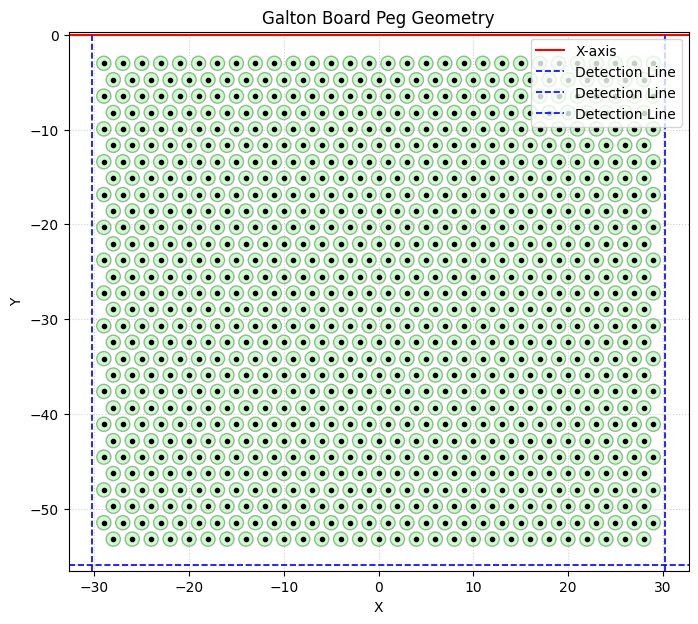

In [103]:
N_FIRST_ROW = 30     # Number of circles in the first row
N_ROWS = 30          # Total number of rows (staggered)
DISTANCE = 2.0      # Center-to-center distance (d)
H_INIT = 3.0        # Initial offset below the x-axis
H_FINAL = 1.0       # Final offset below the x-axis (not used in this code)
RADIUS = 0.75       # Custom radius for all circles
WALL_PADDING = 0.5  # Distance of the wall away from the furthest circle edge

# Generate data
generated_circles, WALL_DISTANCE = generate_circle_geometry(
        n_first_row=N_FIRST_ROW,
        n_rows=N_ROWS,
        d=DISTANCE,
        h_init=H_INIT,
        r_custom=RADIUS,
        WALL_PADDING=WALL_PADDING
    )

# Print out SymPy readable classic equations
print(f"Generated {len(generated_circles)} SymPy Circle Equations")
print(f"Wall distances from the centre: {WALL_DISTANCE}")

# Visualize the results
visualize_circles(generated_circles, H_INIT, N_ROWS, DISTANCE, H_FINAL, WALL_DISTANCE)

Simulation engine which simulates the path for one ball and outputs its termination x-coordinate, and plots its trajectory for quick a visual check.

In [101]:
def simulate_and_visualize_trajectory(circles_data, x_init, y_init, vx_init, vy_init, 
                                      e, h_init, rows, spacing, h_final, WALL_DISTANCE, g=9.81):
    """
    Fixed Galton board simulation and visualization.
    Resolves floating-point root rejection, parabolic tunneling, and includes bounding walls.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Target line extends DOWNWARD
    y_target = -h_init - (rows * spacing * np.cos(np.radians(30))) - h_final
    
    x_imp, y_imp = x_init, y_init
    vx, vy = vx_init, vy_init
    
    ax.scatter([x_imp], [y_imp], color='#2ecc71', marker='o', s=100, label='Release Point', edgecolor='black', zorder=5)
    
    c4 = 0.25 * (g**2)
    step = 0
    all_x, all_y = [x_imp], [y_imp]
    traj_lbl, collision_lbl = False, False
    
    while True:
        step += 1
        
        # 1. Time-to-line solver (Detection Line)
        a_line = 0.5 * g
        b_line = -vy
        c_line = y_target - y_imp
        discriminant = b_line**2 - 4 * a_line * c_line
        
        t_line = float('inf')
        if discriminant >= 0:
            t_candidates = [
                (-b_line + np.sqrt(discriminant)) / (2 * a_line),
                (-b_line - np.sqrt(discriminant)) / (2 * a_line)
            ]
            valid_line_times = [t for t in t_candidates if t > 1e-5]
            if valid_line_times:
                t_line = min(valid_line_times)

        # 2. Time-to-wall solver
        t_wall = float('inf')
        hit_wall_side = None
        
        if vx < 0: # Moving left
            t_left = (-WALL_DISTANCE - x_imp) / vx
            if t_left > 1e-5:
                t_wall = t_left
                hit_wall_side = 'left'
        elif vx > 0: # Moving right
            t_right = (WALL_DISTANCE - x_imp) / vx
            if t_right > 1e-5:
                t_wall = t_right
                hit_wall_side = 'right'

        # 3. Local peg scanning loop
        min_t_circle = float('inf')
        next_peg = None
        
        for circle in circles_data:
            xc, yc = circle["center"]
            R = circle["radius"]
            
            if yc > y_imp + 2.0 * spacing:
                continue
                
            dx = x_imp - xc
            dy = y_imp - yc
            
            c3 = -vy * g
            c2 = (vx**2) + (vy**2) - (dy * g)
            c1 = 2.0 * (dx * vx + dy * vy)
            c0 = (dx**2) + (dy**2) - (R**2)
            
            roots = np.roots([c4, c3, c2, c1, c0])
            for r in roots:
                if abs(r.imag) < 1e-6:
                    t_val = r.real
                    if 1e-5 < t_val < min_t_circle:
                        min_t_circle = t_val
                        next_peg = (xc, yc, R)

        # Intersect evaluation (Find earliest valid event)
        event_times = {'line': t_line, 'peg': min_t_circle, 'wall': t_wall}
        valid_events = {k: v for k, v in event_times.items() if v != float('inf')}
        
        if not valid_events:
            print(f"Simulation out of bounds at step {step}. No intersections found.")
            break
            
        next_event = min(valid_events, key=valid_events.get)
        t_end = valid_events[next_event]
        is_final_step = (next_event == 'line')

        # Generate flight path segment
        t_segment = np.linspace(0, t_end, num=50)
        x_segment = x_imp + vx * t_segment
        y_segment = y_imp + vy * t_segment - 0.5 * g * t_segment**2
        
        all_x.extend(x_segment)
        all_y.extend(y_segment)
        
        lbl_traj = 'Trajectory' if not traj_lbl else ""
        traj_lbl = True
        ax.plot(x_segment, y_segment, color='#2980b9', linewidth=2, label=lbl_traj, zorder=4)
        
        if is_final_step:
            ax.scatter([x_segment[-1]], [y_segment[-1]], color='#2c3e50', marker='X', s=120, 
                       label='Detection Intersection', edgecolor='black', zorder=5)
            print(f"Success! Detection line hit at X = {x_segment[-1]:.6f}")
            break

        # Process Physics
        x_next, y_next = x_segment[-1], y_segment[-1]
        vx_before = vx
        vy_before = vy - g * t_end

        if next_event == 'peg':
            xc, yc, R = next_peg
            nx = (x_next - xc) / R
            ny = (y_next - yc) / R
            
            v_dot_n = vx_before * nx + vy_before * ny
            vx_after = vx_before - (1 + e) * v_dot_n * nx
            vy_after = vy_before - (1 + e) * v_dot_n * ny
            
            lbl_coll = 'Collisions' if not collision_lbl else ""
            collision_lbl = True
            ax.scatter([x_next], [y_next], color='#e74c3c', marker='o', s=30, edgecolor='black', label=lbl_coll, zorder=5)
            
            x_imp = x_next + (nx * 1e-4)
            y_imp = y_next + (ny * 1e-4)
            
        elif next_event == 'wall':
            # Simplified vector math for perfect vertical walls
            vx_after = -e * vx_before
            vy_after = vy_before
            
            lbl_coll = 'Collisions' if not collision_lbl else ""
            collision_lbl = True
            ax.scatter([x_next], [y_next], color='#f39c12', marker='s', s=30, edgecolor='black', label=lbl_coll, zorder=5)
            
            # Normal is 1 (left wall) or -1 (right wall) to bump the ball away
            nx = 1.0 if hit_wall_side == 'left' else -1.0
            x_imp = x_next + (nx * 1e-4)
            y_imp = y_next  # y normal is 0
            
        vx, vy = vx_after, vy_after
        
        if step > 500:
            print("Infinite loop fallback safety triggered.")
            break

    # Draw the pegs and boundaries
    for circle in circles_data:
        xc, yc = circle["center"]
        R = circle["radius"]
        peg_patch = plt.Circle((xc, yc), R, facecolor='#7f8c8d', edgecolor='#34495e', alpha=0.7, zorder=2)
        ax.add_patch(peg_patch)

    # Draw Walls and Floor
    ax.axhline(y=y_target, color='#8e44ad', linestyle='--', linewidth=2, label='Detection Line', zorder=3)
    ax.axvline(x=-WALL_DISTANCE, color='#d35400', linestyle='-', linewidth=2, label='Boundary Wall', zorder=3)
    ax.axvline(x=WALL_DISTANCE, color='#d35400', linestyle='-', linewidth=2, zorder=3)
    
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title('Galton Board Trajectory Simulation')
    ax.grid(True, linestyle=':', alpha=0.5)
    
    if circles_data:
        cx = [c["center"][0] for c in circles_data]
        cy = [c["center"][1] for c in circles_data]
        # Pad the x-limits using WALL_DISTANCE instead of peg positions
        ax.set_xlim(-WALL_DISTANCE - (spacing), WALL_DISTANCE + (spacing))
        ax.set_ylim(y_target - spacing * 2, max(max(cy) + spacing * 2, y_init + 1))
    
    handles, labels = ax.get_legend_handles_labels()
    unique_legend_map = dict(zip(labels, handles))
    ax.legend(unique_legend_map.values(), unique_legend_map.keys(), loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return all_x[-1] if is_final_step else None

Success! Detection line hit at X = 11.999010


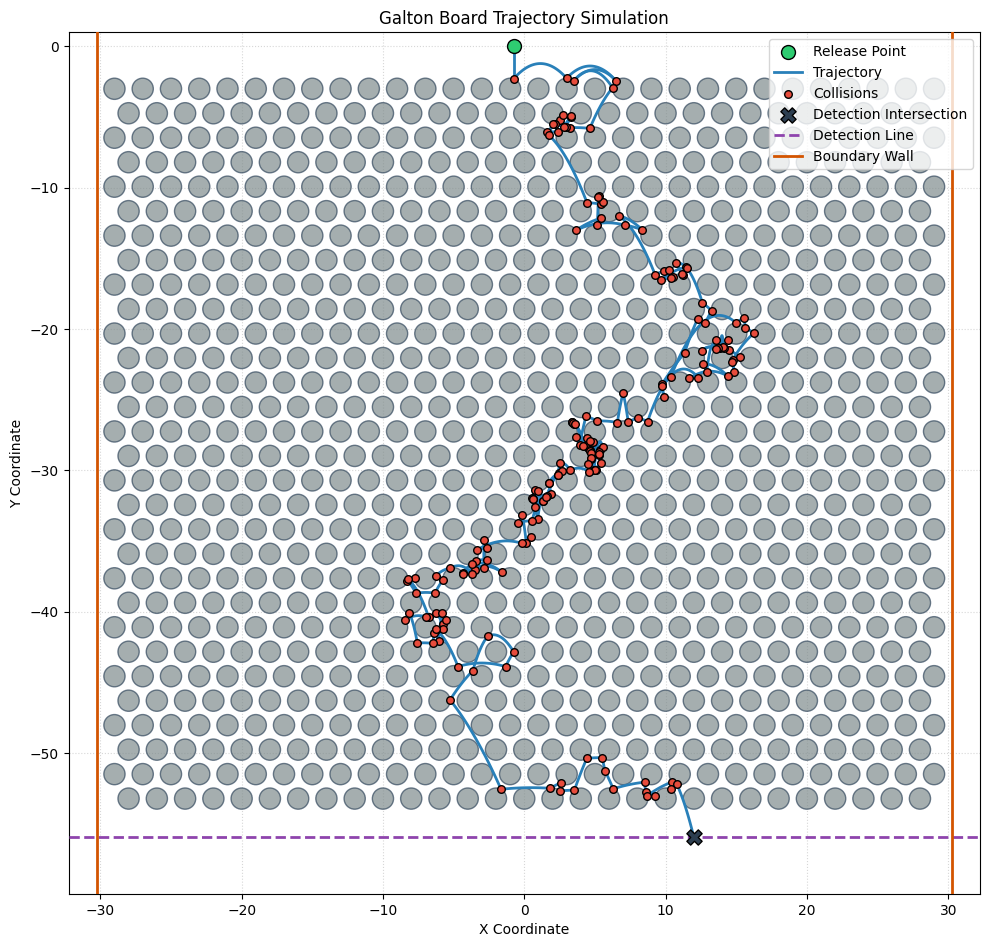

np.float64(11.999010271499145)

In [ ]:
x_init = np.random.uniform(-1.0, 1.0)
y_init = 0.0
vx_init = 0.0
vy_init = 0.0
e = 0.9

# simulate_ball_trajectory(
#     generated_circles,
#     x_init, y_init,
#     vx_init, vy_init,
#     e, H_INIT, N_ROWS, DISTANCE, H_FINAL
# )

simulate_and_visualize_trajectory(
    generated_circles,
    x_init, y_init,
    vx_init, vy_init,
    e, H_INIT, N_ROWS, DISTANCE, H_FINAL, WALL_DISTANCE
)
